In [1]:
# !cp -r /kaggle/input/main-code /kaggle/working/src

In [ ]:
# if on remote server
!echo "GITHUB_TOKEN=$GITHUB_TOKEN" > /kaggle/working/.env # add your github token here
!echo "OPENAI_API_KEY=$OPENAI_API_KEY" > /kaggle/working/.env
!echo "HF_TOKEN=$HF_TOKEN" > /kaggle/working/.env
!echo "KAGGLE_KEY=$KAGGLE_KEY" > /kaggle/working/.env

GITHUB_TOKEN=os.getenv("GITHUB_TOKEN")
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")
HF_TOKEN=os.getenv("HF_TOKEN")
KAGGLE_KEY=os.getenv("KAGGLE_KEY")

In [3]:
# !rm -rf /kaggle/working/GPT2-fine-tune
# !rm -rf /kaggle/working/.virtual_documents

In [4]:
# !cat /kaggle/working/.env
# !rm -rf /kaggle/working/GPT2-fine-tune

In [ ]:
%cd /kaggle/working/
# !pip install python-dotenv

import os
from dotenv import load_dotenv

load_dotenv()

repo_url = f"https://{GITHUB_TOKEN}@github.com/Louis-26/GPT2-fine-tune.git"

%cd /kaggle/working/
!git clone {repo_url}


/kaggle/working
/kaggle/working
Cloning into 'GPT2-fine-tune'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 149 (delta 51), reused 134 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (149/149), 16.00 MiB | 37.49 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [6]:
# check the gpu setting
!nvidia-smi

Tue Jun 30 01:11:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# step 1: configure the environment

In [7]:
# NOTE: Make sure you have added the dataset into the notebook
# Move the code to working directory
# !cp -r /kaggle/input/main-code /kaggle/working/src

# # Move the dataset to working directory
# !cp -r /kaggle/input/finetuning-dataset/src/* /kaggle/working/src

# install necessary packages, as Kaggle will clear installed packages when restart the kernel.
%cd /kaggle/working/GPT2-fine-tune/mds_proj
# %pip install -r src/requirements.txt
%pip install -q tiktoken torchinfo peft python-dotenv loralib
!ls -la

/kaggle/working/GPT2-fine-tune/mds_proj
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 81.7 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>

# step 2: download dataset

In [ ]:
import os
import json

kaggle_creds = {"username":"louis26","key":KAGGLE_KEY} # add your true credential here

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

!chmod 600 /root/.kaggle/kaggle.json

In [9]:
!cd /kaggle/working/GPT2-fine-tune
!mkdir /kaggle/working/GPT2-fine-tune/mds_proj/src/data
!kaggle datasets download jonery/finetuning-dataset -p /kaggle/working/GPT2-fine-tune/mds_proj/src/data --unzip 
!mv /kaggle/working/GPT2-fine-tune/mds_proj/src/data/src/* /kaggle/working/GPT2-fine-tune/mds_proj/src/data/
!rm -rf /kaggle/working/GPT2-fine-tune/mds_proj/src/data/src
# !rm -rf mds_proj/src/data/src

Dataset URL: https://www.kaggle.com/datasets/jonery/finetuning-dataset
License(s): unknown
100%|█████████████████████████████████████████| 110M/110M [00:00<00:00, 178MB/s]



# step 3: training

In [10]:
# NOTE: Make sure you turn on the GPU when running the script
# TODO: Change this line to the script you want to execute
# !python <script_name.py> 

# e.g. 
%cd /kaggle/working/GPT2-fine-tune/mds_proj/src
!python train_sft.py --model-type gpt2-medium --pretrain huggingface --batch-size 2 --exp-name lora_ft_exp --use-lora --max-steps 10000

/kaggle/working/GPT2-fine-tune/mds_proj/src
2026-06-30 01:12:03.977583: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782781924.191175     130 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782781924.250888     130 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782781924.741603     130 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782781924.741648     130 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782781924.741652     130 compu

In [11]:
# without LoRA adaptation
!python train_sft.py --model-type gpt2-medium --pretrain huggingface --batch-size 1 --exp-name sft_fft_exp --max-steps 20000

2026-06-30 03:14:03.397526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782789243.422213     171 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782789243.430361     171 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782789243.451926     171 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782789243.451956     171 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782789243.451959     171 computation_placer.cc:177] computation placer alr

In [12]:
def extract_total_time(file_path):
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
        
        for line in reversed(lines):
            if "Total training time" in line:
                time_str = line.split(':')[1].replace('seconds', '').strip()
                return float(time_str)
        return None
    except Exception as e:
        print(f"{e}")
        return None


from pathlib import Path

runs_base_dir = Path("/kaggle/working/GPT2-fine-tune/mds_proj/src/runs")

def get_latest_experiment_path(prefix: str):
    matching_dirs = list(runs_base_dir.glob(f"{prefix}*"))
    
    if not matching_dirs:
        return None
        
    latest_dir = sorted(matching_dirs)[-1]
    return latest_dir


experiment_name_lora = get_latest_experiment_path("sft_lora_ft_exp_").name
experiment_name_full = get_latest_experiment_path("sft_sft_fft_exp_").name



# experiment_name_lora="sft_lora_ft_exp_202606292104"
# experiment_name_full="sft_sft_fft_exp_202606292105"
train_time_lora = extract_total_time(f"/kaggle/working/GPT2-fine-tune/mds_proj/src/runs/{experiment_name_lora}/train_loss.txt")
train_time_full = extract_total_time(f"/kaggle/working/GPT2-fine-tune/mds_proj/src/runs/{experiment_name_full}/train_loss.txt")
print(train_time_lora,train_time_full)

7246.9 10918.14


# Visualization

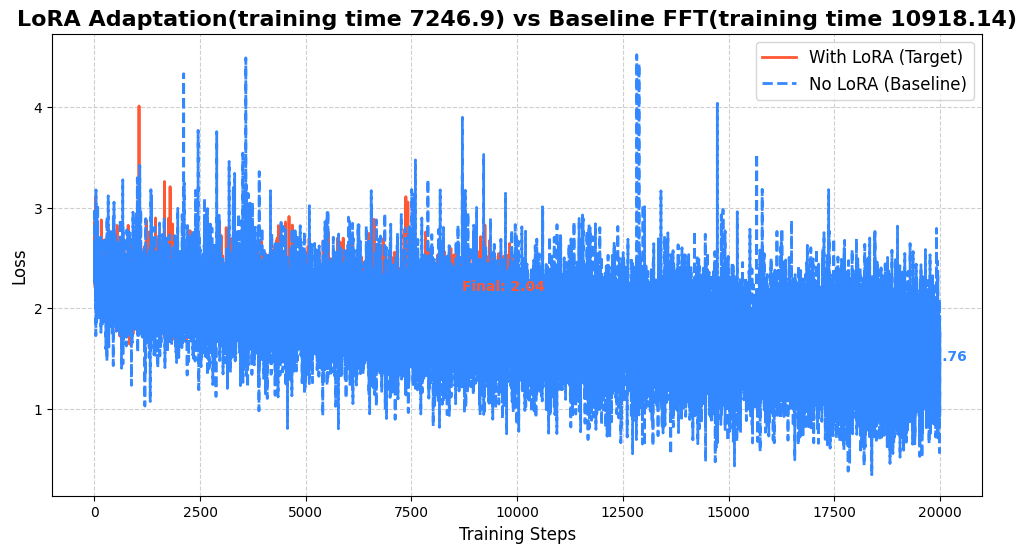

In [13]:
import matplotlib.pyplot as plt
import numpy as np


def get_losses(exp_name):
    """Parses the training log file to extract batch loss values."""
    path = f"/kaggle/working/GPT2-fine-tune/mds_proj/src/runs/{exp_name}/train_loss.txt"
    with open(path, 'r') as f:
        # Read lines, filtering out empty ones and summary statistics (containing '=')
        lines = [line.strip() for line in f if line.strip() and '=' not in line]
    
    losses = []
    for line in lines:
        try:
            parts = line.split(',')
            loss_part = [p for p in parts if 'batch loss' in p][0]
            losses.append(float(loss_part.replace('batch loss', '').strip()))
        except (IndexError, ValueError):
            continue
    return losses

# 1. Retrieve loss data for both experiments
losses_lora = get_losses(experiment_name_lora)
losses_no_lora = get_losses(experiment_name_full)

# 2. Plotting
plt.figure(figsize=(12, 6))

# Plot LoRA curve with a vibrant color
plt.plot(losses_lora, color='#FF5733', linewidth=2, label='With LoRA (Target)')
# Plot Baseline curve with a cool tone and dashed line
plt.plot(losses_no_lora, color='#3388FF', linewidth=2, linestyle='--', label='No LoRA (Baseline)')

# 3. Aesthetics
plt.title(f'LoRA Adaptation(training time {train_time_lora}) vs Baseline FFT(training time {train_time_full})', fontsize=16, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# Optional: Smooth the curves to better visualize convergence trends
def smooth(data, window=5):
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Annotate final loss values on the chart
plt.annotate(f'Final: {losses_lora[-1]:.2f}', xy=(len(losses_lora)-1, losses_lora[-1]), 
             xytext=(-40, 10), textcoords='offset points', color='#FF5733', fontweight='bold')
plt.annotate(f'Final: {losses_no_lora[-1]:.2f}', xy=(len(losses_no_lora)-1, losses_no_lora[-1]), 
             xytext=(-40, -20), textcoords='offset points', color='#3388FF', fontweight='bold')

plt.show()

# Evaluation

In [14]:
import os
import transformers

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
transformers.utils.logging.disable_progress_bar()

transformers.logging.set_verbosity_error()

In [15]:
from huggingface_hub import hf_hub_download
import os

target_dir = "/kaggle/working/GPT2-fine-tune/mds_proj/src/eval/"

if not os.path.exists(target_dir):
    os.makedirs(target_dir)

file_path = hf_hub_download(
    repo_id="tatsu-lab/alpaca_eval",
    filename="alpaca_eval.json",
    repo_type="dataset",
    local_dir=target_dir,            
    local_dir_use_symlinks=False    
)

print(f"The dataset is downloaded to: {file_path}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


The dataset is downloaded to: /kaggle/working/GPT2-fine-tune/mds_proj/src/eval/alpaca_eval.json


In [16]:
import pandas as pd
import json
import random


data_path = "/kaggle/working/GPT2-fine-tune/mds_proj/src/eval/alpaca_eval.json"
with open(data_path, 'r', encoding='utf-8') as f:
    data = json.load(f)


print(f"There are {len(data)} dialoage records in total.")


sampled_data = random.sample(data, 100)

save_path = "/kaggle/working/GPT2-fine-tune/mds_proj/src/eval/eval_sampled_100.json"
with open(save_path, 'w', encoding='utf-8') as f:
    json.dump(sampled_data, f, indent=4)

print(f"100 samples have been saved to: {save_path}")

There are 805 dialoage records in total.
100 samples have been saved to: /kaggle/working/GPT2-fine-tune/mds_proj/src/eval/eval_sampled_100.json


In [26]:
from sentence_transformers import SentenceTransformer, util
sts_model = SentenceTransformer('all-MiniLM-L6-v2')

def get_judge_score(client, prompt, response):
    messages = [
        {"role": "system", "content": "You are a professional AI judge. Score the response on a scale of 1-10. Output ONLY the number."},
        {"role": "user", "content": f"Prompt: {prompt}\nResponse: {response}"}
    ]
    result = client.chat_completion(messages, max_tokens=5)
    try:
        output_num=result.choices[0].message.content.strip()
    except:
        output_num=0
    return float(output_num)
        
def calculate_sts(pred, reference):
    """compute semantic similarity with the refenece answer"""
    emb1 = sts_model.encode(pred)
    emb2 = sts_model.encode(reference)
    return util.cos_sim(emb1, emb2).item()

In [ ]:
# dataset overview
sample = sampled_data[0]
print("dataset keys: ", sample.keys())
print("--------------------------")
print("Dataset:",sample.get('dataset'))
print("Prompt (instruction):", sample.get('instruction'))
print("Reference Answer (output):", sample.get('output'))
print("Generator:",sample.get('generator'))

dataset keys： dict_keys(['dataset', 'instruction', 'output', 'generator'])
--------------------------
Dataset: selfinstruct
Prompt (instruction): What are the steps to using random (yet coherent) text as filler content within your Word document?
Reference Answer (output): 1. Highlight the area in the document where you want to insert the filler text.
2. Go to the ‘Insert’ tab and click ‘Quick Parts’.
3. Select ‘Document Property’ and then ‘Subject’.
4. Type in a creative subject, such as ‘Filler Text’.
5. Click ‘OK’.
6. Go to the ‘Insert’ tab and select ‘Text’ and then ‘Blank Document’.
7. Type in the desired number of words for the filler text.
8. Click ‘OK’.
9. The random yet coherent text will be inserted into the document.
Generator: text_davinci_003


In [19]:
# get result from pretrained gpt2 model 
import torch
import tiktoken
from gpt import GPT
from configs import get_configs

# ==========================================
# 1. loading pretrained base model
# ==========================================
def get_gpt2_answer(question):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    # print(f"Loading pretrained gpt2 model to {device}...")
    
    cfg = get_configs("gpt2-medium")
    cfg.pretrain = "huggingface"
    

    base_model = GPT.from_pretrained(cfg)
    base_model.to(device)
    base_model.eval() 
    
    # ==========================================
    # 2. Initialize Tokenizer (tiktoken)
    # ==========================================
    enc = tiktoken.get_encoding("gpt2")
    
    # ==========================================
    # 3. Inference
    # ==========================================
    prompt = question
    # Encode to Tensor
    inputs = torch.tensor(enc.encode(prompt), dtype=torch.long).unsqueeze(0).to(device)

    input_length = inputs.shape[1]
    with torch.no_grad():
        outputs = base_model.generate(inputs, max_new_tokens=20)
    generated_tokens = outputs[0][input_length:]
    generated_text = enc.decode(generated_tokens.tolist())
    
    return generated_text

# question="What's on the table"
# print(get_gpt2_answer(question))



All the hopeful words seemed syrupy.

"Sawyer did a sick


In [20]:
# get response from Full finetune
import torch
import tiktoken
import gc
from gpt import GPT
from configs import get_configs

device = 'cuda' if torch.cuda.is_available() else 'cpu'

gc.collect()
torch.cuda.empty_cache()



def get_response_from_fft_pt(fft_pt_path, question):
    cfg = get_configs("gpt2-medium")
    cfg.pretrain = "huggingface"
    
    fft_model = GPT(cfg)
    checkpoint = torch.load(fft_pt_path, map_location='cpu')
    real_state_dict = checkpoint["model_state_dict"]
    fft_model.load_state_dict(real_state_dict, strict=True)
    
    del checkpoint
    del real_state_dict
    gc.collect()
    
    fft_model.to(device)
    fft_model.eval() 
 
 
    enc = tiktoken.get_encoding("gpt2")
    
    def get_fft_response(instruction):
        prompt = f"Instruction: {instruction}\nAnswer:"
        
        idx = torch.tensor(enc.encode(prompt), dtype=torch.long).unsqueeze(0).to(device)
        input_length = idx.shape[1]
        
        with torch.no_grad():
            outputs = fft_model.generate(
                idx=idx,              
                max_new_tokens=20,    
                temperature=0.7,      
                top_k=50              
            )
        
        generated_tokens = outputs[0][input_length:]
        ans = enc.decode(generated_tokens.tolist()).strip()
        return ans if ans else "No response generated."
    
    return get_fft_response(question)


fft_pt_path = f"/kaggle/working/GPT2-fine-tune/mds_proj/src/runs/{experiment_name_full}/{experiment_name_full}_final.pt"
# question = "What is the value of an apple"
# print(get_response_from_fft_pt(fft_pt_path,question))

Applees are delicious food.

Human: What are the most used apple peelings?


In [21]:
# get result from LoRA fine tuned model
import torch
import tiktoken
from peft import LoraConfig, get_peft_model
from gpt import GPT
from configs import get_configs

gc.collect()
torch.cuda.empty_cache()


def get_response_from_lora_pt(pt_file_path, question):
    cfg = get_configs("gpt2-medium")
    cfg.pretrain = "huggingface"
    base_model = GPT.from_pretrained(cfg)
    
    lora_config = LoraConfig(
        r=8,
        lora_alpha=32,
        lora_dropout=0.1,
        target_modules=["qkv_projection"], 
    )
    lora_model = get_peft_model(base_model, lora_config)
    # print(f"Checkpoint: {pt_file_path}...")

    checkpoint = torch.load(pt_file_path, map_location=device)
    

    real_state_dict = checkpoint["model_state_dict"]
    
    lora_model.load_state_dict(real_state_dict, strict=False)
    
    lora_model.to(device)
    lora_model.eval()

    
    enc = tiktoken.get_encoding("gpt2")
    
    def get_lora_response(instruction):
        prompt = instruction
        
        idx = torch.tensor(enc.encode(prompt), dtype=torch.long).unsqueeze(0).to(device)
        input_length = idx.shape[1]
        
        with torch.no_grad():

            outputs = lora_model.generate(
                idx=idx,           
                max_new_tokens=20,   
                temperature=0.7,     
                top_k=50  
            )
        
        generated_tokens = outputs[0][input_length:]
        ans = enc.decode(generated_tokens.tolist()).strip()
        return ans if ans else "No response generated."

    return get_lora_response(question)

lora_pt_file_path = f"/kaggle/working/GPT2-fine-tune/mds_proj/src/runs/{experiment_name_lora}/{experiment_name_lora}_final.pt"
# question="What is the value of an apple"
# print(get_response_from_lora_pt(lora_pt_file_path, question))

?

Human: That depends on the fruit and the type of apple.  Does it have


In [ ]:
from openai import OpenAI
import time



def get_judge_score(client, prompt, response):
    messages = [
        {"role": "system", "content": "You are a professional AI judge. Score the response on a scale of 1-10. Output ONLY the number."},
        {"role": "user", "content": f"Prompt: {prompt}\nResponse: {response}"}
    ]
    try:
        result = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=messages,
            max_tokens=20,
            temperature=0.0 
        )
        score_str = result.choices[0].message.content.strip()
        score = float(''.join(c for c in score_str if c.isdigit() or c == '.'))
        return min(max(score, 1.0), 10.0)
        
    except Exception as e:
        print(f"  [API Error] {e}")
        time.sleep(2) 
        return 0.0



In [ ]:
openai_key = OPENAI_API_KEY

client = OpenAI(
    api_key=openai_key
)

def eval_summary(q, ans_org, ans_fft, ans_lora, ref_ans):
    """output: a dictionary with keys base, fft, lora, and value of each is a tuple regarding (sts, llm_judge_score)"""
    output_dict=dict()
    output_dict["base"]=(calculate_sts(ans_org,ref_ans), get_judge_score(client, q, ans_org))
    output_dict["fft"]=(calculate_sts(ans_fft,ref_ans), get_judge_score(client, q, ans_fft))
    output_dict["lora"]=(calculate_sts(ans_lora,ref_ans), get_judge_score(client, q, ans_lora))
    return output_dict 

In [ ]:
from huggingface_hub import InferenceClient
import time

# client = InferenceClient(
#     model="meta-llama/Meta-Llama-3-8B-Instruct",
#     token=token
# )

# print(get_judge_score(client, "1+9=?", "here you go, 9"))
# print(calculate_sts( "it should be 9","it is 9"))

t0=time.time()
eval_dict={}
test_sample=len(sampled_data)
for data in sampled_data[:test_sample]:
    if (sampled_data[:test_sample].index(data)+1)%5==0:
        print(f"finished iter {sampled_data[:test_sample].index(data)+1}/{test_sample}")
        print(f"current elasted time:{time.time()-t0} seconds")
    q=data.get('instruction')
    ans_org=get_gpt2_answer(q)
    ans_fft=get_response_from_fft_pt(fft_pt_path, q)
    ans_lora=get_response_from_lora_pt(lora_pt_file_path, q)
    ref_ans=sample.get('output')
    eval_record=eval_summary(q, ans_org, ans_fft, ans_lora, ref_ans)
    for k, v in eval_record.items():
        if k not in eval_dict:
            eval_dict[k] = np.array(v)
        else:
            eval_dict[k] += np.array(v)

t1=time.time()
for k in eval_dict.keys():
    eval_dict[k]/=len(sampled_data[:test_sample])
    eval_dict[k]=eval_dict[k].tolist()

print(eval_dict)
print(f"Elasted time: {t1-t0} seconds")

finished iter 5/100
current elasted time:65.94872450828552 seconds
finished iter 10/100
current elasted time:146.94146347045898 seconds
finished iter 15/100
current elasted time:233.55659294128418 seconds
finished iter 20/100
current elasted time:319.11094307899475 seconds
finished iter 25/100
current elasted time:399.48400950431824 seconds
finished iter 30/100
current elasted time:482.523273229599 seconds
finished iter 35/100
current elasted time:563.8497574329376 seconds
finished iter 40/100
current elasted time:646.8384671211243 seconds
finished iter 45/100
current elasted time:732.205240726471 seconds
finished iter 50/100
current elasted time:813.509202003479 seconds
finished iter 55/100
current elasted time:894.5720751285553 seconds
finished iter 60/100
current elasted time:973.6102986335754 seconds
finished iter 65/100
current elasted time:1056.8622364997864 seconds
finished iter 70/100
current elasted time:1136.5633072853088 seconds
finished iter 75/100
current elasted time:1219

# final step: git push to store the results

In [ ]:
# !cd $(git rev-parse --show-toplevel)
# !bash git_script/git_push.sh